# Preprocessing & Modeling
## Random Forest Regression untuk Prediksi Penjualan UMKM

## Step 1: Import Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

print('✅ Semua library berhasil di-import')

✅ Semua library berhasil di-import


## Step 2: Load Data dari Notebook EDA

In [42]:
# Load dataset
data_path = '../data/raw/dummy_dataset.csv'
df = pd.read_csv(data_path)
print(f"✅ Data loaded: {df.shape}")
print(f"\n📝 Columns: {df.columns.tolist()}")
print(f"\n🔍 First 5 rows:")
print(df.head())

✅ Data loaded: (500, 4)

📝 Columns: ['tanggal', 'nama_produk', 'harga', 'jumlah']

🔍 First 5 rows:
      tanggal     nama_produk  harga  jumlah
0  2026-05-11            Oreo  13977      12
1  2026-05-08            Oreo  17248      21
2  2026-05-08  Keripik Pisang  15735      25
3  2026-05-08      Bolu Kukus  15973      25
4  2026-05-11      Bolu Kukus  17688      24


## Step 3: Handle Missing Values

In [43]:
df_preproc = df.copy()
target_col = 'jumlah' if 'jumlah' in df_preproc.columns else 'jumlah_terjual'

numeric_cols = df_preproc.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_preproc.select_dtypes(include=['object', 'category']).columns.tolist()

print("="*80)
print("📌 MISSING VALUES:")
print("="*80)

missing_counts = df_preproc.isnull().sum()
if missing_counts.sum() > 0:
    print(missing_counts[missing_counts > 0])
else:
    print("✅ Tidak ada missing value")

# Fill numeric
for col in numeric_cols:
    if df_preproc[col].isnull().any():
        df_preproc[col].fillna(df_preproc[col].median(), inplace=True)

# Fill categorical
for col in categorical_cols:
    if df_preproc[col].isnull().any():
        df_preproc[col].fillna(df_preproc[col].mode()[0], inplace=True)

print("✅ Missing values handled")

📌 MISSING VALUES:
✅ Tidak ada missing value
✅ Missing values handled


## Step 4: Handle Outliers dengan IQR

In [44]:
df_out = df_preproc.copy()

print("="*80)
print("🔍 OUTLIER DETECTION & HANDLING:")
print("="*80)

for col in numeric_cols:
    if col == target_col:
        continue
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_out[(df_out[col] < lower_bound) | (df_out[col] > upper_bound)]
    print(f"  {col}: {len(outliers)} outliers, bounds=[{lower_bound:.2f}, {upper_bound:.2f}]")
    
    df_out[col] = np.where(df_out[col] < lower_bound, lower_bound,
                           np.where(df_out[col] > upper_bound, upper_bound, df_out[col]))

print("\n✅ Outliers handled")

🔍 OUTLIER DETECTION & HANDLING:
  harga: 0 outliers, bounds=[6451.25, 25893.25]

✅ Outliers handled


## Step 5: Categorical Encoding

In [45]:
df_encoded = df_out.copy()

print("="*80)
print("🔤 CATEGORICAL ENCODING & TIME FEATURES:")
print("="*80)

# Encode nama_produk dengan LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encoded['nama_produk'] = le.fit_transform(df_encoded['nama_produk'])
print(f"✅ Label Encoding untuk nama_produk: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Buat fitur waktu dari tanggal
df_encoded['tanggal'] = pd.to_datetime(df_encoded['tanggal'])
df_encoded['hari'] = df_encoded['tanggal'].dt.day
df_encoded['bulan'] = df_encoded['tanggal'].dt.month
df_encoded['tahun'] = df_encoded['tanggal'].dt.year
df_encoded['hari_dalam_minggu'] = df_encoded['tanggal'].dt.dayofweek  # 0=Senin, 6=Minggu
df_encoded['is_weekend'] = df_encoded['hari_dalam_minggu'].apply(lambda x: 1 if x >= 5 else 0)
df_encoded['minggu_dalam_bulan'] = df_encoded['tanggal'].apply(lambda x: (x.day - 1) // 7 + 1)
df_encoded['kuartal'] = df_encoded['tanggal'].dt.quarter

# Drop kolom tanggal asli
df_encoded = df_encoded.drop('tanggal', axis=1)

print("✅ Fitur waktu berhasil dibuat: hari, bulan, tahun, hari_dalam_minggu, is_weekend, minggu_dalam_bulan, kuartal")
print(f"\n📊 Shape setelah encoding: {df_encoded.shape}")

🔤 CATEGORICAL ENCODING & TIME FEATURES:
✅ Label Encoding untuk nama_produk: {'Bolu Kukus': 0, 'Keripik Pisang': 1, 'Kopi Bubuk': 2, 'Oreo': 3}
✅ Fitur waktu berhasil dibuat: hari, bulan, tahun, hari_dalam_minggu, is_weekend, minggu_dalam_bulan, kuartal

📊 Shape setelah encoding: (500, 10)


## Step 6: Feature Scaling

In [55]:
numeric_cols_scaled = [col for col in df_encoded.select_dtypes(include=[np.number]).columns if col != target_col]

print("="*80)
print("📐 FEATURE SCALING - StandardScaler:")
print("="*80)

print("\n📊 STATISTIK SEBELUM SCALING:")
print(df_encoded[numeric_cols_scaled].describe().T[['mean', 'std', 'min', 'max']])

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_cols_scaled] = scaler.fit_transform(df_scaled[numeric_cols_scaled])

print("\n📊 STATISTIK SETELAH SCALING:")
print(df_scaled[numeric_cols_scaled].describe().T[['mean', 'std', 'min', 'max']])
print("\n✅ Feature scaling selesai")

# Simpan scaler untuk digunakan di aplikasi
scaler_path = '../model/scaler.pkl'
Path(scaler_path).parent.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, scaler_path)
print(f"💾 Scaler saved to: {scaler_path}")

📐 FEATURE SCALING - StandardScaler:

📊 STATISTIK SEBELUM SCALING:
                         mean          std      min      max
nama_produk             1.432     1.113488      0.0      3.0
harga               16172.592  2790.316186  11511.0  20954.0
hari                   10.006     1.998487      7.0     13.0
bulan                   5.000     0.000000      5.0      5.0
tahun                2026.000     0.000000   2026.0   2026.0
hari_dalam_minggu       3.024     1.999856      0.0      6.0
is_weekend              0.286     0.452342      0.0      1.0
minggu_dalam_bulan      1.864     0.343132      1.0      2.0
kuartal                 2.000     0.000000      2.0      2.0

📊 STATISTIK SETELAH SCALING:
                            mean       std       min       max
nama_produk         1.776357e-17  1.001002 -1.287337  1.409598
harga              -2.060574e-16  1.001002 -1.672305  1.715288
hari               -1.350031e-16  1.001002 -1.505644  1.499633
bulan               0.000000e+00  0.000000

## Step 7: Feature Selection

✨ FEATURE SELECTION:

✅ Menggunakan semua 9 fitur untuk model:
   - nama_produk: korelasi = -0.0747
   - harga: korelasi = 0.0380
   - hari: korelasi = -0.0548
   - bulan: korelasi = nan
   - tahun: korelasi = nan
   - hari_dalam_minggu: korelasi = -0.0044
   - is_weekend: korelasi = -0.0590
   - minggu_dalam_bulan: korelasi = -0.0831
   - kuartal: korelasi = nan


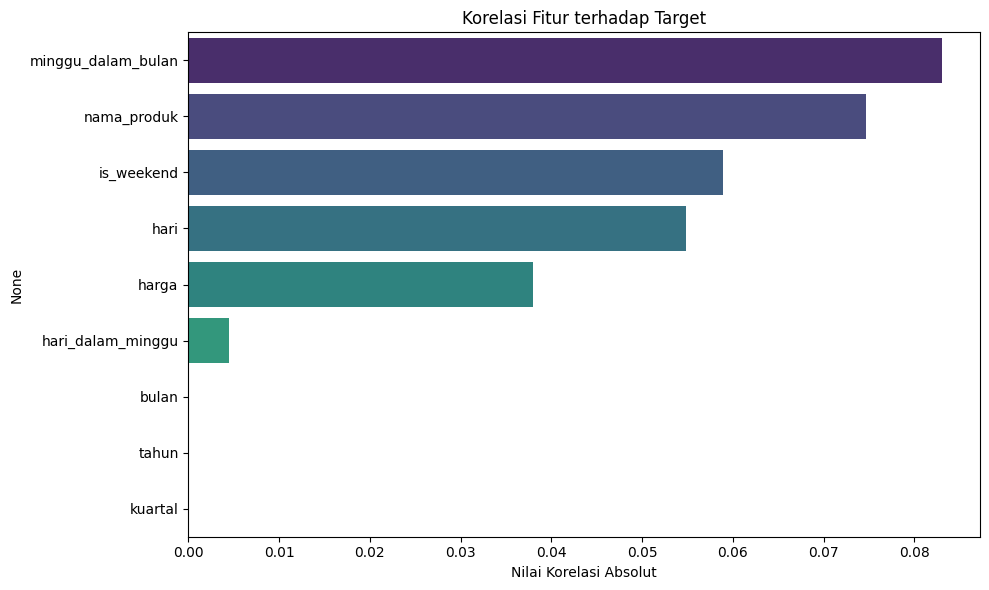

In [47]:
print("="*80)
print("✨ FEATURE SELECTION:")
print("="*80)

# Untuk aplikasi, gunakan semua fitur kecuali target
selected_features = [col for col in df_scaled.columns if col != target_col]
print(f"\n✅ Menggunakan semua {len(selected_features)} fitur untuk model:")
for feat in selected_features:
    corr_val = df_scaled.corr()[target_col].loc[feat]
    print(f"   - {feat}: korelasi = {corr_val:.4f}")

# Plot korelasi
corr_with_target = df_scaled.corr()[target_col].abs().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
corr_plot = corr_with_target.drop(target_col)
sns.barplot(x=corr_plot.values, y=corr_plot.index, palette='viridis')
plt.title("Korelasi Fitur terhadap Target")
plt.xlabel("Nilai Korelasi Absolut")
plt.tight_layout()
plt.show()

## Step 8: Train-Test Split

In [48]:
print("="*80)
print("📊 TRAIN-TEST SPLIT (80:20):")
print("="*80)

X = df_scaled[selected_features].copy()
y = df_scaled[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"\n✅ Split configuration:")
print(f"   Total samples: {len(X)}")
print(f"   Training samples: {len(X_train)} (80%)")
print(f"   Testing samples: {len(X_test)} (20%)")
print(f"\n📊 Shape:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")

📊 TRAIN-TEST SPLIT (80:20):

✅ Split configuration:
   Total samples: 500
   Training samples: 400 (80%)
   Testing samples: 100 (20%)

📊 Shape:
   X_train: (400, 9)
   X_test:  (100, 9)
   y_train: (400,)
   y_test:  (100,)


## Step 9: Training Random Forest

In [54]:
print("="*80)
print("🌳 TRAINING RANDOM FOREST REGRESSOR:")
print("="*80)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print(f"\n📋 Model configuration:")
print(f"   n_estimators: {rf_model.n_estimators}")
print(f"   max_depth: {rf_model.max_depth}")

print(f"\n🔧 Training dengan {len(X_train)} samples...")
rf_model.fit(X_train, y_train)
print("✅ Training completed!")

# Save model
model_path = '../model/rf_model.pkl'
Path(model_path).parent.mkdir(parents=True, exist_ok=True)
joblib.dump(rf_model, model_path)
print(f"💾 Model saved to: {model_path}")

🌳 TRAINING RANDOM FOREST REGRESSOR:

📋 Model configuration:
   n_estimators: 100
   max_depth: 10

🔧 Training dengan 400 samples...
✅ Training completed!
💾 Model saved to: ../model/rf_model.pkl


## Step 10: Model Evaluation

In [50]:
print("="*80)
print("📊 MODEL EVALUATION & METRICS:")
print("="*80)

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"\n📈 PERFORMANCE METRICS:")
print(f"\n  TRAIN SET:")
print(f"    MAE:  {mae_train:.4f}")
print(f"    RMSE: {rmse_train:.4f}")
print(f"    R²:   {r2_train:.4f}")

print(f"\n  TEST SET:")
print(f"    MAE:  {mae_test:.4f}")
print(f"    RMSE: {rmse_test:.4f}")
print(f"    R²:   {r2_test:.4f}")

print(f"\n💡 INTERPRETASI:")
if r2_test > 0.7:
    print(f"    ✅ Model performance: BAIK (R² > 0.7)")
elif r2_test > 0.5:
    print(f"    🟡 Model performance: SEDANG (0.5 < R² < 0.7)")
else:
    print(f"    ⚠️ Model performance: PERLU IMPROVEMENT (R² < 0.5)")

📊 MODEL EVALUATION & METRICS:

📈 PERFORMANCE METRICS:

  TRAIN SET:
    MAE:  3.6264
    RMSE: 4.2733
    R²:   0.5123

  TEST SET:
    MAE:  5.8755
    RMSE: 6.9292
    R²:   -0.1740

💡 INTERPRETASI:
    ⚠️ Model performance: PERLU IMPROVEMENT (R² < 0.5)


## Step 11: Feature Importance

🔥 FEATURE IMPORTANCE:



📊 Top fitur berdasarkan importance:
  harga                ████████████████████████████████ 0.6530
  nama_produk          ██████ 0.1350
  hari                 ████ 0.0957
  hari_dalam_minggu    ████ 0.0927
  is_weekend            0.0149
  minggu_dalam_bulan    0.0087
  bulan                 0.0000
  tahun                 0.0000
  kuartal               0.0000


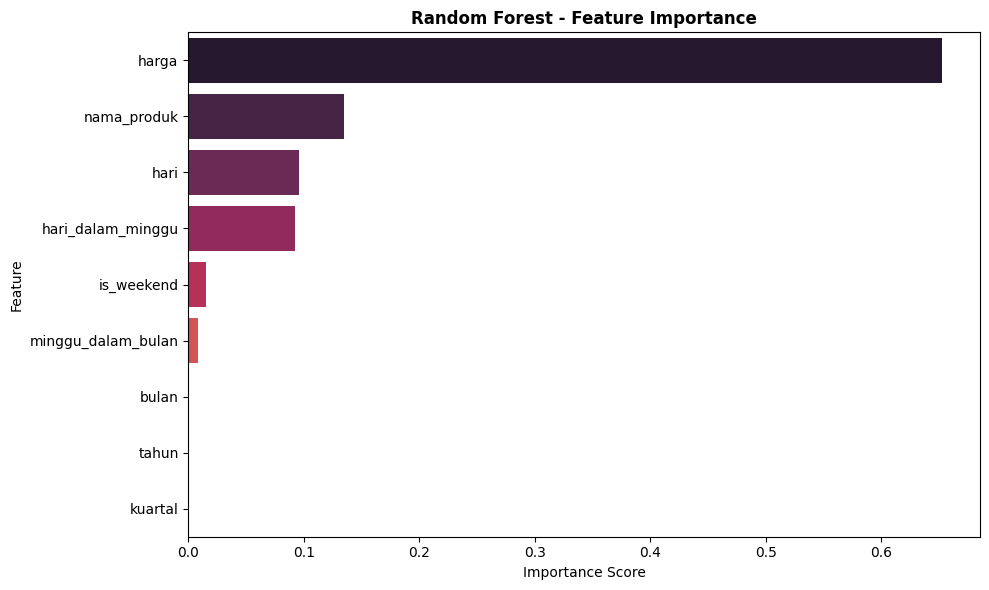

In [51]:
print("="*80)
print("🔥 FEATURE IMPORTANCE:")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top fitur berdasarkan importance:")
for idx, row in feature_importance.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"  {row['feature']:20s} {bar} {row['importance']:.4f}")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='rocket')
plt.title("Random Forest - Feature Importance", fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Step 12: Visualisasi Prediksi vs Actual

📈 PREDICTION vs ACTUAL VISUALIZATION:


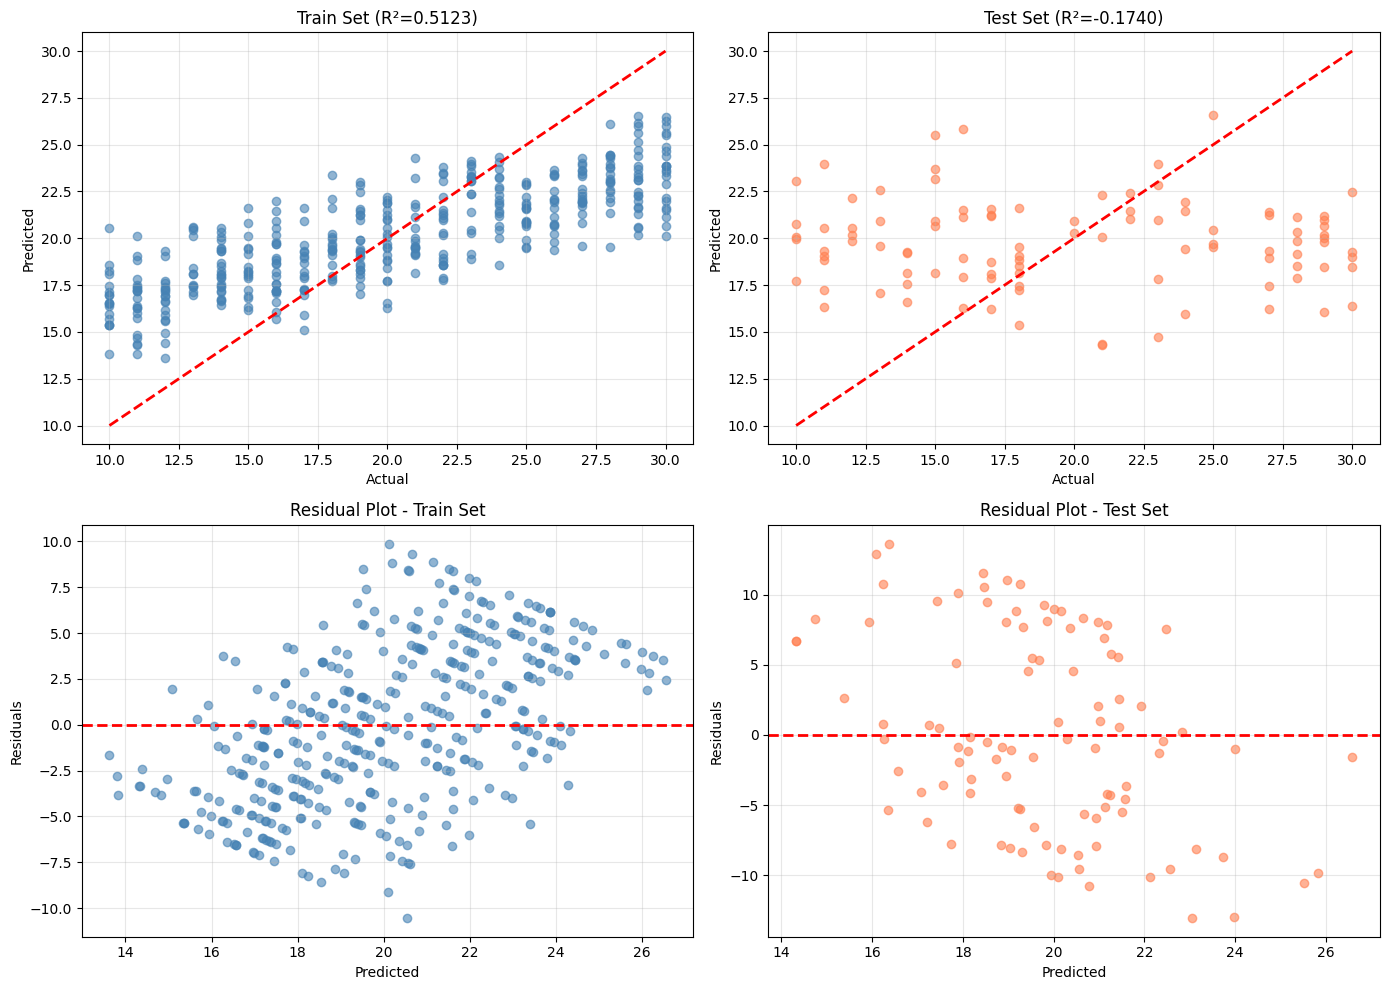


✅ Visualisasi selesai!


In [52]:
print("="*80)
print("📈 PREDICTION vs ACTUAL VISUALIZATION:")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot train
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.6, color='steelblue')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Train Set (R²={r2_train:.4f})')
axes[0, 0].grid(True, alpha=0.3)

# Scatter plot test
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.6, color='coral')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'Test Set (R²={r2_test:.4f})')
axes[0, 1].grid(True, alpha=0.3)

# Residual train
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.6, color='steelblue')
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot - Train Set')
axes[1, 0].grid(True, alpha=0.3)

# Residual test
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.6, color='coral')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residual Plot - Test Set')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualisasi selesai!")

In [53]:
# Load model dan periksa
loaded_model = joblib.load('../model/rf_model.pkl')
print(f"Model loaded: {loaded_model}")
print(f"Jumlah fitur yang diharapkan: {loaded_model.n_features_in_}")
print(f"Fitur yang digunakan saat training: {selected_features}")

Model loaded: RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_jobs=-1, random_state=42)
Jumlah fitur yang diharapkan: 9
Fitur yang digunakan saat training: ['nama_produk', 'harga', 'hari', 'bulan', 'tahun', 'hari_dalam_minggu', 'is_weekend', 'minggu_dalam_bulan', 'kuartal']
